# 🧤 Smart Glove — Prediction Notebook

Notebook ini berisi **2 mode**:
1. **Training + Simpan Model** — wajib dijalankan dulu sekali
2. **Prediksi dari CSV** — test dengan file CSV baru

---
### Cara Pakai
- Jalankan **Cell 1 (Konfigurasi)** → sesuaikan path
- Jalankan **Cell 2 (Install)** → sekali saja
- Jalankan **Cell 3–5 (Training)** → hasilkan `model.pkl` dan `scaler.pkl`
- Jalankan **Cell 6 (Prediksi CSV)** → prediksi dari file CSV baru
- Opsional: **Cell 7 (Debug)** → analisis detail 1 file CSV

---
## ⚙️ Cell 1 — KONFIGURASI (Edit di sini)

In [2]:
# ════════════════════════════════════════════════════════════
#  EDIT BAGIAN INI SESUAI SETUP KAMU
# ════════════════════════════════════════════════════════════

# Path folder CSV training (berisi 0_rep1.csv, 1_rep2.csv, dst)
DATA_PATH   = r"C:\FOLDERKU\SmartGlove\datashet\angka"

# Folder output model + scaler
OUTPUT_DIR  = r"C:\FOLDERKU\SmartGlove\model_output"

# Daftar gesture — sesuaikan dengan yang kamu punya
GESTURES    = ['0', '1', '2', '3']

# Jumlah frame per sampel (harus sama dengan waktu rekam kamu)
WINDOW_SIZE = 80

# ════════════════════════════════════════════════════════════
print("✓ Konfigurasi tersimpan")
print(f"  DATA_PATH  : {DATA_PATH}")
print(f"  OUTPUT_DIR : {OUTPUT_DIR}")
print(f"  GESTURES   : {GESTURES}")


✓ Konfigurasi tersimpan
  DATA_PATH  : C:\FOLDERKU\SmartGlove\datashet\angka
  OUTPUT_DIR : C:\FOLDERKU\SmartGlove\model_output
  GESTURES   : ['0', '1', '2', '3']


---
## 📦 Cell 2 — Install Dependencies (Sekali Saja)

In [2]:
# Jalankan sekali. Kalau sudah pernah, skip cell ini.
import subprocess, sys

packages = ['scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'joblib']
for pkg in packages:
    result = subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], capture_output=True)
    status = '✓' if result.returncode == 0 else '✗'
    print(f"  {status} {pkg}")

print("\nDone! Lanjut ke Cell 3.")

  ✓ scikit-learn
  ✓ pandas
  ✓ numpy
  ✓ matplotlib
  ✓ seaborn
  ✓ joblib

Done! Lanjut ke Cell 3.


---
## 🏋️ Cell 3 — Load Data + Augmentasi

In [3]:
import os, sys, warnings
import numpy as np
import pandas as pd
from glob import glob
from collections import defaultdict
warnings.filterwarnings('ignore')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Definisi kolom sensor ───────────────────────────────────────────────────
FLEX_COLS = [f'flex{i}_L' for i in range(1,6)] + [f'flex{i}_R' for i in range(1,6)]
IMU_COLS  = ['accX_L','accY_L','accZ_L','gyroX_L','gyroY_L','gyroZ_L',
             'accX_R','accY_R','accZ_R','gyroX_R','gyroY_R','gyroZ_R']
ALL_COLS  = FLEX_COLS + IMU_COLS
N_FEATURES = len(ALL_COLS)

# ── Helper: baca + padding CSV ──────────────────────────────────────────────
def load_csv_as_window(fpath, window_size=WINDOW_SIZE):
    """Baca CSV, ambil ALL_COLS, padding/truncate ke window_size."""
    df = pd.read_csv(fpath)
    missing = [c for c in ALL_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Kolom missing: {missing}")
    arr = df[ALL_COLS].values.astype(np.float32)
    if len(arr) >= window_size:
        arr = arr[-window_size:]
    else:
        pad = np.zeros((window_size - len(arr), arr.shape[1]), dtype=np.float32)
        arr = np.vstack([pad, arr])
    return arr

# ── Helper: augmentasi ──────────────────────────────────────────────────────
def augment(arr, n=4):
    results = [arr]
    for _ in range(n):
        aug = arr.copy()
        aug += np.random.normal(0, 0.01, arr.shape).astype(np.float32)
        aug *= np.random.uniform(0.92, 1.08)
        if np.random.random() > 0.5:
            factor  = np.random.uniform(0.85, 1.15)
            old_len = arr.shape[0]
            new_len = int(old_len * factor)
            if new_len > 10:
                idx    = np.linspace(0, old_len-1, new_len)
                warped = np.array([np.interp(idx, np.arange(old_len), arr[:,j])
                                   for j in range(arr.shape[1])]).T
                if len(warped) >= WINDOW_SIZE:
                    aug = warped[-WINDOW_SIZE:].astype(np.float32)
                else:
                    pad = np.zeros((WINDOW_SIZE - len(warped), warped.shape[1]))
                    aug = np.vstack([pad, warped]).astype(np.float32)
        results.append(np.clip(aug, -5, 5))
    return results

# ── Load semua CSV ──────────────────────────────────────────────────────────
raw_data  = []
label_map = {g: i for i, g in enumerate(GESTURES)}

print("Loading CSV...")
for gesture in GESTURES:
    # coba pola _rep dulu, fallback ke nama apapun
    files = sorted(glob(os.path.join(DATA_PATH, f"{gesture}_rep*.csv")))
    if not files:
        files = sorted(glob(os.path.join(DATA_PATH, f"{gesture}*.csv")))

    ok = 0
    for fpath in files:
        try:
            arr = load_csv_as_window(fpath)
            raw_data.append({'gesture': gesture, 'label': label_map[gesture], 'data': arr})
            ok += 1
        except Exception as e:
            print(f"  ⚠ Skip {os.path.basename(fpath)}: {e}")

    status = '✓' if ok > 0 else '✗'
    print(f"  {status} Gesture '{gesture}': {ok} file")

if not raw_data:
    raise RuntimeError(f"Tidak ada data! Cek DATA_PATH: {DATA_PATH}")

# ── Augmentasi ──────────────────────────────────────────────────────────────
X, y = [], []
for item in raw_data:
    for aug_arr in augment(item['data'], n=4):
        X.append(aug_arr)
        y.append(item['label'])

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print(f"\n✓ Dataset siap: {X.shape}  |  {len(GESTURES)} kelas  |  {len(raw_data)} raw file")

Loading CSV...
  ✓ Gesture '0': 5 file
  ✓ Gesture '1': 5 file
  ✓ Gesture '2': 5 file
  ✓ Gesture '3': 5 file

✓ Dataset siap: (100, 80, 22)  |  4 kelas  |  20 raw file


---
## 🤖 Cell 4 — Training + Evaluasi

Training dengan 5-Fold Cross Validation...

  Fold 1: 100.0%
  Fold 2: 100.0%
  Fold 3: 100.0%
  Fold 4: 100.0%
  Fold 5: 100.0%

  Accuracy: 100.0% ± 0.0%


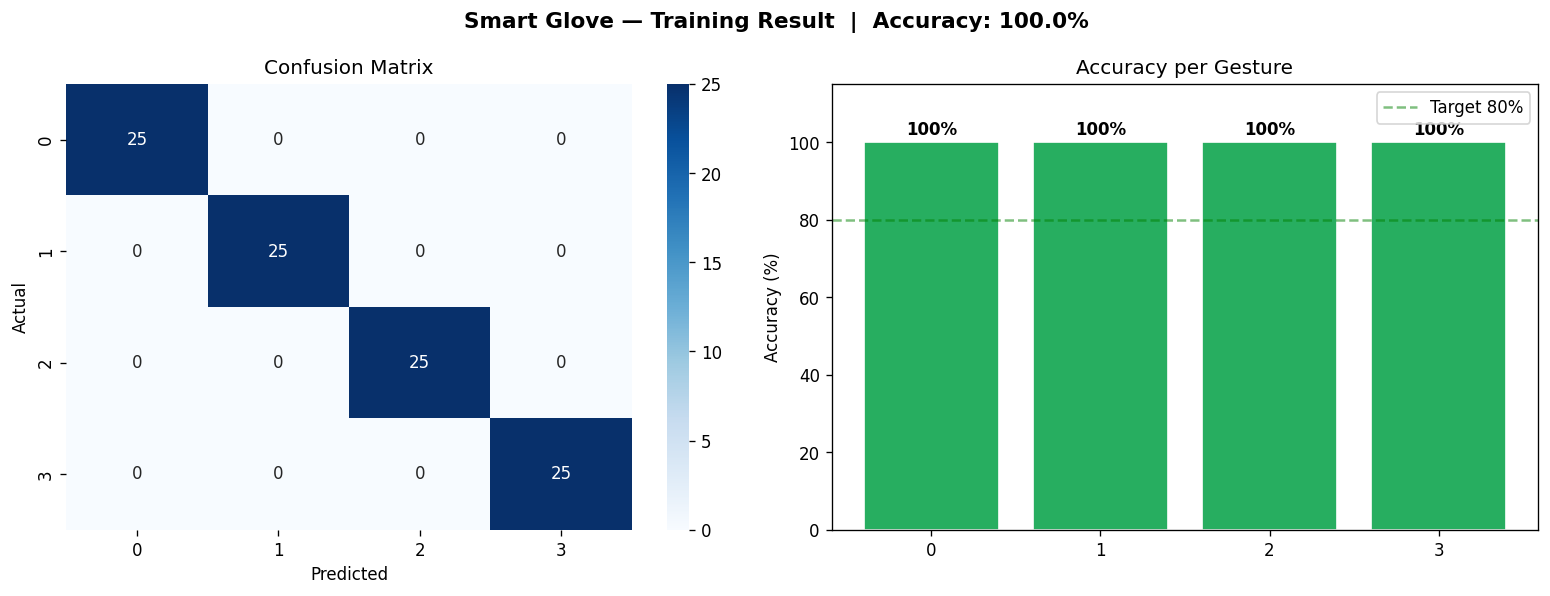


✓ Grafik tersimpan: C:\FOLDERKU\SmartGlove\model_output\training_result.png

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        25
           3       1.00      1.00      1.00        25

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [4]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, Image as IPImage
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score)

# Flatten: (N, WINDOW, FEATURES) → (N, WINDOW*FEATURES)
X_flat   = X.reshape(len(X), -1)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

clf      = RandomForestClassifier(n_estimators=200, random_state=42,
                                   max_depth=None, n_jobs=-1)
kf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accs, all_preds, all_true = [], [], []

print("Training dengan 5-Fold Cross Validation...\n")
for fold, (tr_idx, te_idx) in enumerate(kf.split(X_scaled, y)):
    clf.fit(X_scaled[tr_idx], y[tr_idx])
    preds = clf.predict(X_scaled[te_idx])
    acc   = accuracy_score(y[te_idx], preds)
    fold_accs.append(acc)
    all_preds.extend(preds)
    all_true.extend(y[te_idx])
    print(f"  Fold {fold+1}: {acc*100:.1f}%")

mean_acc = np.mean(fold_accs)
print(f"\n  Accuracy: {mean_acc*100:.1f}% ± {np.std(fold_accs)*100:.1f}%")

# ── Confusion Matrix ────────────────────────────────────────────────────────
cm     = confusion_matrix(all_true, all_preds)
# Gunakan label aktual dari data, bukan GESTURES (jaga-jaga jika ada kelas kosong)
actual_classes = sorted(set(all_true) | set(all_preds))
labels = [GESTURES[i] for i in actual_classes]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Smart Glove — Training Result  |  Accuracy: {mean_acc*100:.1f}%',
             fontsize=13, fontweight='bold')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

per_acc = cm.diagonal() / cm.sum(axis=1)
colors  = ['#27ae60' if a >= .8 else '#e67e22' if a >= .6 else '#e74c3c'
           for a in per_acc]
axes[1].bar(labels, per_acc*100, color=colors, edgecolor='white')
axes[1].axhline(80, color='green', ls='--', alpha=.5, label='Target 80%')
axes[1].set_ylim(0, 115)
axes[1].set_title('Accuracy per Gesture')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
for i, (g, a) in enumerate(zip(labels, per_acc)):
    axes[1].text(i, a*100+2, f'{a*100:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()

# Simpan & tampilkan di Jupyter
out_png = os.path.join(OUTPUT_DIR, 'training_result.png')
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.close()
display(IPImage(out_png))
print("\n✓ Grafik tersimpan:", out_png)

# ── Classification Report ────────────────────────────────────────────────────
print("\n── Classification Report ──────────────────────────────")
print(classification_report(all_true, all_preds, target_names=GESTURES))


---
## 💾 Cell 5 — Simpan Model (WAJIB sebelum prediksi)

In [6]:
import joblib

# Train ulang dengan SELURUH data (bukan hanya fold terakhir)
print("Training final dengan seluruh data...")
clf_final = RandomForestClassifier(n_estimators=200, random_state=42,
                                    max_depth=None, n_jobs=-1)
clf_final.fit(X_scaled, y)

# Simpan
model_path  = os.path.join(OUTPUT_DIR, 'model.pkl')
scaler_path = os.path.join(OUTPUT_DIR, 'scaler.pkl')
meta_path   = os.path.join(OUTPUT_DIR, 'meta.pkl')

joblib.dump(clf_final, model_path)
joblib.dump(scaler,    scaler_path)
joblib.dump({'gestures': GESTURES, 'window_size': WINDOW_SIZE,
             'all_cols': ALL_COLS, 'label_map': label_map}, meta_path)

print(f"✓ model.pkl   → {model_path}")
print(f"✓ scaler.pkl  → {scaler_path}")
print(f"✓ meta.pkl    → {meta_path}")
print("\nModel siap dipakai untuk prediksi!")

Training final dengan seluruh data...
✓ model.pkl   → C:\FOLDERKU\SmartGlove\model_output\model.pkl
✓ scaler.pkl  → C:\FOLDERKU\SmartGlove\model_output\scaler.pkl
✓ meta.pkl    → C:\FOLDERKU\SmartGlove\model_output\meta.pkl

Model siap dipakai untuk prediksi!


---
## 📂 Cell 6 — PREDIKSI DARI CSV

Taruh satu atau lebih file CSV baru di folder manapun, isi path-nya di bawah.

In [7]:
import joblib
import os
import numpy as np
import pandas as pd
from glob import glob

# ── EDIT: path CSV yang mau diprediksi ─────────────────────────────────────
# Bisa satu file, bisa satu folder (akan dibaca semua CSV-nya)
PREDICT_SOURCE = r"C:\FOLDERKU\SmartGlove\test_csv"   # folder atau file .csv
# ───────────────────────────────────────────────────────────────────────────

# Load model
model_path  = os.path.join(OUTPUT_DIR, 'model.pkl')
scaler_path = os.path.join(OUTPUT_DIR, 'scaler.pkl')
meta_path   = os.path.join(OUTPUT_DIR, 'meta.pkl')

clf_pred  = joblib.load(model_path)
scl_pred  = joblib.load(scaler_path)
meta      = joblib.load(meta_path)
GESTURES_ = meta['gestures']
ALL_COLS_ = meta['all_cols']
WIN_      = meta['window_size']

print(f"✓ Model loaded  |  {len(GESTURES_)} gesture: {GESTURES_}")

# Kumpulkan daftar file
if os.path.isfile(PREDICT_SOURCE):
    csv_files = [PREDICT_SOURCE]
else:
    csv_files = sorted(glob(os.path.join(PREDICT_SOURCE, '*.csv')))

if not csv_files:
    raise FileNotFoundError(f"Tidak ada CSV di: {PREDICT_SOURCE}")

print(f"\nMemproses {len(csv_files)} file...\n")
print(f"{'File':<35} {'Prediksi':^12} {'Confidence':^12} {'True Label':^12} {'Status'}")
print("─" * 85)

results = []
for fpath in csv_files:
    fname = os.path.basename(fpath)
    # Coba deteksi label true dari nama file (misal: 3_rep2_...csv → '3')
    true_label = None
    for g in GESTURES_:
        if fname.startswith(g + '_') or fname.startswith(g + '.'):
            true_label = g
            break

    try:
        # Load & preprocess
        df  = pd.read_csv(fpath)
        arr = df[ALL_COLS_].values.astype(np.float32)
        if len(arr) >= WIN_:
            arr = arr[-WIN_:]
        else:
            pad = np.zeros((WIN_ - len(arr), arr.shape[1]), dtype=np.float32)
            arr = np.vstack([pad, arr])

        x_flat  = arr.flatten().reshape(1, -1)
        x_sc    = scl_pred.transform(x_flat)
        pred_idx = clf_pred.predict(x_sc)[0]
        proba    = clf_pred.predict_proba(x_sc)[0]
        pred_g   = GESTURES_[pred_idx]
        conf     = proba[pred_idx] * 100

        # Bandingkan dengan label true jika ada
        if true_label is not None:
            correct = '✓ BENAR' if pred_g == true_label else '✗ SALAH'
        else:
            true_label = '?'
            correct = '—'

        print(f"{fname:<35} {pred_g:^12} {conf:>9.1f}%   {true_label:^12} {correct}")
        results.append({'file': fname, 'predicted': pred_g,
                        'confidence': conf, 'true': true_label,
                        'correct': correct})

    except Exception as e:
        print(f"{fname:<35} ERROR: {e}")

# Ringkasan akurasi jika semua file punya label
labeled = [r for r in results if r['true'] != '?']
if labeled:
    n_correct = sum(1 for r in labeled if '✓' in r['correct'])
    print(f"\n{'─'*85}")
    print(f"Akurasi prediksi CSV: {n_correct}/{len(labeled)}  ({n_correct/len(labeled)*100:.1f}%)")
    avg_conf = np.mean([r['confidence'] for r in results])
    print(f"Confidence rata-rata : {avg_conf:.1f}%")

✓ Model loaded  |  4 gesture: ['0', '1', '2', '3']

Memproses 12 file...

File                                  Prediksi    Confidence   True Label  Status
─────────────────────────────────────────────────────────────────────────────────────
0_rep1_20260328_094304.csv               0            57.0%        0       ✓ BENAR
0_rep2_20260328_094314.csv               0            54.5%        0       ✓ BENAR
0_rep3_20260328_094324.csv               0            55.0%        0       ✓ BENAR
1_rep1_20260328_094344.csv               1            96.0%        1       ✓ BENAR
1_rep2_20260328_094354.csv               1            96.5%        1       ✓ BENAR
1_rep3_20260328_094403.csv               1            92.5%        1       ✓ BENAR
2_rep1_20260328_094417.csv               2            94.0%        2       ✓ BENAR
2_rep2_20260328_094426.csv               2            59.0%        2       ✓ BENAR
2_rep3_20260328_094435.csv               2            82.5%        2       ✓ BENAR
3_rep1_2026

---
## 🔍 Cell 8 — Debug: Cek 1 File CSV Secara Detail

In [9]:
# ── EDIT: path file yang mau di-debug ──────────────────────────────────────
DEBUG_FILE = r"C:\FOLDERKU\SmartGlove\test_csv\0_rep1_20260328_094304.csv"
# ───────────────────────────────────────────────────────────────────────────

import joblib, os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

meta      = joblib.load(os.path.join(OUTPUT_DIR, 'meta.pkl'))
clf_dbg   = joblib.load(os.path.join(OUTPUT_DIR, 'model.pkl'))
scl_dbg   = joblib.load(os.path.join(OUTPUT_DIR, 'scaler.pkl'))
GEST_     = meta['gestures']
ALL_COLS_ = meta['all_cols']
WIN_      = meta['window_size']

df = pd.read_csv(DEBUG_FILE)
print(f"File    : {os.path.basename(DEBUG_FILE)}")
print(f"Rows    : {len(df)}")
print(f"Columns : {list(df.columns)}")
print()

# Preprocess
arr = df[ALL_COLS_].values.astype(np.float32)
if len(arr) >= WIN_:
    arr = arr[-WIN_:]
else:
    pad = np.zeros((WIN_ - len(arr), arr.shape[1]), dtype=np.float32)
    arr = np.vstack([pad, arr])

x_flat   = arr.flatten().reshape(1, -1)
x_sc     = scl_dbg.transform(x_flat)
pred_idx = clf_dbg.predict(x_sc)[0]
proba    = clf_dbg.predict_proba(x_sc)[0]

print("── Hasil Prediksi ───────────────────────────────")
print(f"Prediksi : {GEST_[pred_idx]}  (confidence: {proba[pred_idx]*100:.1f}%)")
print("\nDistribusi probabilitas semua gesture:")
for g, p in zip(GEST_, proba):
    bar = '█' * int(p * 40)
    print(f"  {g}: {bar:<40} {p*100:.1f}%")

# Plot sensor signal
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
fig.suptitle(f'Debug: {os.path.basename(DEBUG_FILE)}  →  Prediksi: {GEST_[pred_idx]}',
             fontweight='bold')

FLEX_COLS = [c for c in ALL_COLS_ if 'flex' in c]
IMU_COLS  = [c for c in ALL_COLS_ if c not in FLEX_COLS]

for col in FLEX_COLS:
    idx = ALL_COLS_.index(col)
    axes[0].plot(arr[:, idx], label=col, alpha=.8)
axes[0].set_title('Flex Sensors')
axes[0].legend(ncol=5, fontsize=7)
axes[0].set_ylabel('Value')

for col in IMU_COLS[:6]:  # hanya IMU kiri agar tidak penuh
    idx = ALL_COLS_.index(col)
    axes[1].plot(arr[:, idx], label=col, alpha=.8)
axes[1].set_title('IMU Kiri (6 channel pertama)')
axes[1].legend(ncol=6, fontsize=7)
axes[1].set_ylabel('Value')
axes[1].set_xlabel('Frame')

plt.tight_layout()
out = os.path.join(OUTPUT_DIR, 'debug_signal.png')
plt.savefig(out, dpi=110, bbox_inches='tight')
plt.show()
print(f"\n✓ Plot disimpan: {out}")

File    : 0_rep1_20260328_094304.csv
Rows    : 274
Columns : ['timestamp', 'flex1_L', 'flex2_L', 'flex3_L', 'flex4_L', 'flex5_L', 'accX_L', 'accY_L', 'accZ_L', 'gyroX_L', 'gyroY_L', 'gyroZ_L', 'flex1_R', 'flex2_R', 'flex3_R', 'flex4_R', 'flex5_R', 'accX_R', 'accY_R', 'accZ_R', 'gyroX_R', 'gyroY_R', 'gyroZ_R', 'repetition']

── Hasil Prediksi ───────────────────────────────
Prediksi : 0  (confidence: 57.0%)

Distribusi probabilitas semua gesture:
  0: ██████████████████████                   57.0%
  1: ███████████                              28.0%
  2: █████                                    13.5%
  3:                                          1.5%

✓ Plot disimpan: C:\FOLDERKU\SmartGlove\model_output\debug_signal.png
